# Projeto 1 — Forecast Modeling

## Objetivo
Construir e comparar modelos de previsão semanal de demanda por categoria, avaliando o desempenho em um período de teste e selecionando o modelo mais adequado para alimentar o planejamento financeiro.

### Estrutura
1. Carregamento da base tratada
2. Agregação semanal por categoria
3. Separação treino/teste
4. Baselines
5. Holt-Winters
6. Métricas de avaliação
7. Seleção do melhor modelo
8. Forecast futuro
9. Exportação das previsões


## 1. Bibliotecas e leitura da base


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ARQUIVO = "retail_sales_cleaned_project1.csv"

df = pd.read_csv(ARQUIVO, parse_dates=["date"])
df.head()


,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,day_of_week_original,weekday_was_correct,year,month,month_name,quarter,week,is_weekend,gross_revenue,effective_price_est,net_sales_est
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Thursday,Friday,False,2024,9,September,3,38,False,32334,"1,902.00","32,334.00"
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Saturday,Wednesday,False,2024,12,December,4,51,True,36806,"2,629.00","36,806.00"
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Friday,Saturday,False,2024,9,September,3,39,False,62200,"2,488.00","62,200.00"
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Sunday,Tuesday,False,2024,6,June,2,24,True,2051,278.35,"1,948.45"
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Thursday,Saturday,False,2024,12,December,4,49,False,91390,"1,976.00","73,112.00"


## 2. Construção da série semanal

A previsão será feita por `category`, agregando as unidades vendidas por semana.

A escolha semanal reduz parte do ruído diário e gera uma granularidade mais adequada para planejamento comercial e financeiro.


In [2]:
weekly = (
    df.set_index("date")
      .groupby("category")
      .resample("W-SUN")
      .agg(
          units_sold=("units_sold", "sum"),
          net_sales_est=("net_sales_est", "sum"),
          avg_price=("price", "mean"),
          avg_discount=("discount_percent", "mean"),
          avg_inventory=("inventory_level", "mean")
      )
      .reset_index()
)

weekly.head()


,category,date,units_sold,net_sales_est,avg_price,avg_discount,avg_inventory
0,Clothing,2024-01-07,184,"230,721.20","1,391.25",3.75,311.62
1,Clothing,2024-01-14,372,"543,797.10","1,609.67",3.75,221.58
2,Clothing,2024-01-21,261,"508,324.40","1,997.40",8.00,226.30
3,Clothing,2024-01-28,352,"392,885.90","1,190.69",6.54,249.08
4,Clothing,2024-02-04,405,"665,047.00","1,775.93",8.21,198.14


In [3]:
print("Semanas disponíveis por categoria:")
display(
    weekly.groupby("category")["date"]
          .agg(["min", "max", "count"])
)


Semanas disponíveis por categoria:


,min,max,count
category,,,
Clothing,2024-01-07,2025-01-05,53
Electronics,2024-01-07,2025-01-05,53
Grocery,2024-01-07,2025-01-05,53
Home,2024-01-07,2025-01-05,53
Personal Care,2024-01-07,2025-01-05,53


## 3. Visualização das séries

Antes de modelar, observamos o comportamento semanal por categoria.


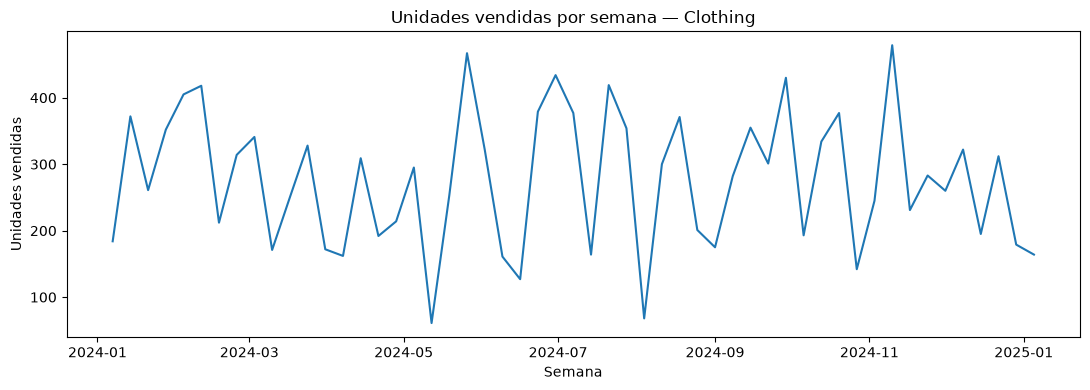

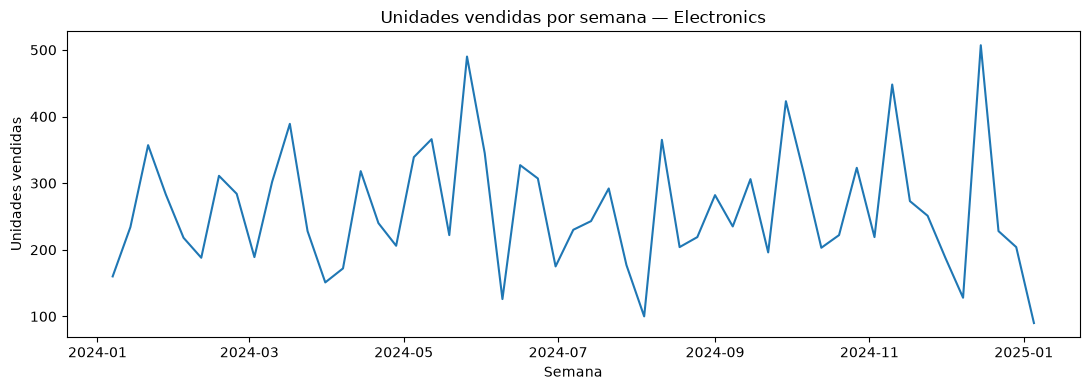

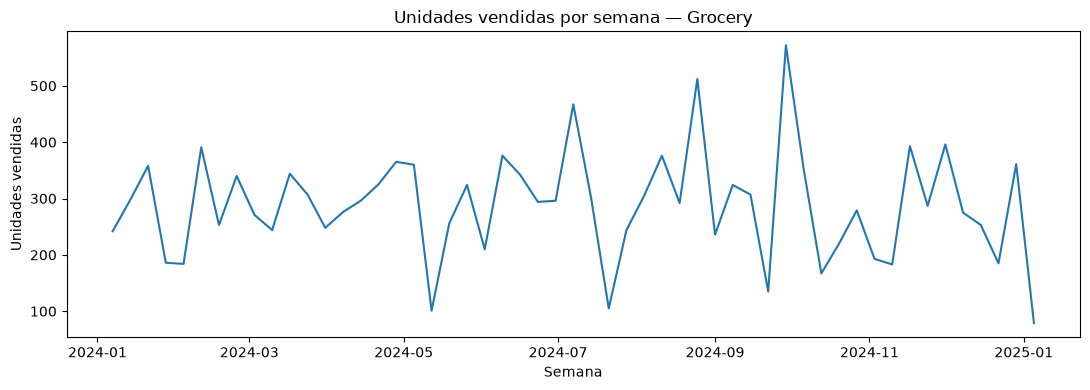

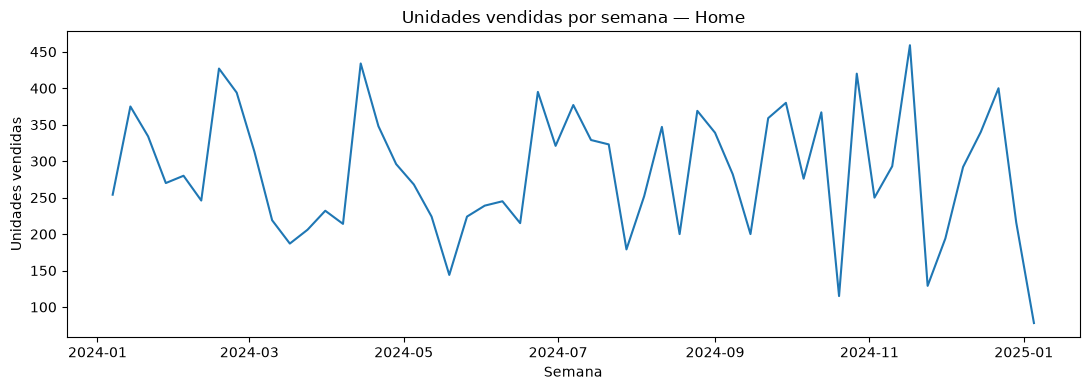

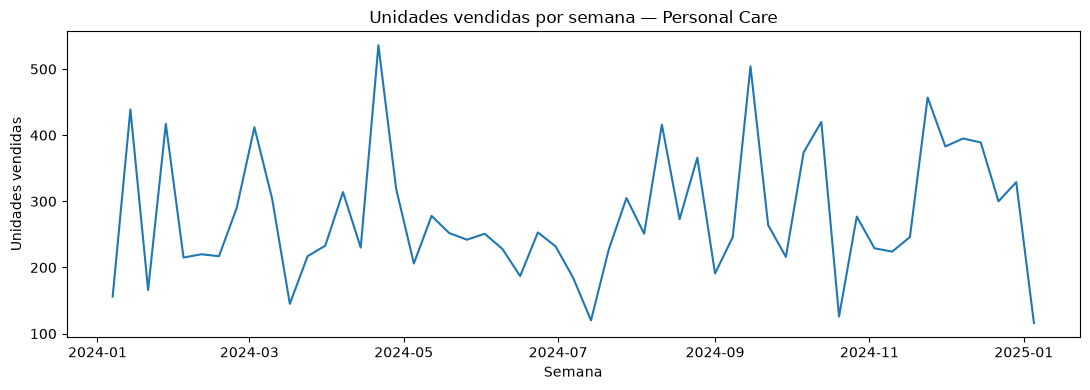

In [4]:
for categoria in weekly["category"].unique():
    temp = weekly[weekly["category"] == categoria]

    plt.figure(figsize=(11, 4))
    plt.plot(temp["date"], temp["units_sold"])
    plt.title(f"Unidades vendidas por semana — {categoria}")
    plt.xlabel("Semana")
    plt.ylabel("Unidades vendidas")
    plt.tight_layout()
    plt.show()


## 4. Separação treino e teste

Usaremos as últimas 8 semanas como período de teste.

Isso simula uma situação real em que o modelo é treinado com o histórico disponível e testado contra semanas futuras já conhecidas.


In [5]:
TEST_WEEKS = 8

def split_train_test(data):
    data = data.sort_values("date").copy()
    train = data.iloc[:-TEST_WEEKS]
    test = data.iloc[-TEST_WEEKS:]
    return train, test


## 5. Funções de avaliação

Usaremos:

- **MAE**: erro absoluto médio
- **RMSE**: penaliza erros maiores
- **MAPE**: erro percentual médio
- **Bias**: indica tendência sistemática de superestimar ou subestimar


In [6]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def bias(y_true, y_pred):
    return np.mean(np.array(y_pred) - np.array(y_true))


def avaliar_modelo(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "Bias": bias(y_true, y_pred)
    }


## 6. Modelos baseline

Antes de utilizar um modelo estatístico, estabelecemos referências simples.

### Baseline 1 — Naive
A próxima semana recebe o valor da última semana observada.

### Baseline 2 — Média móvel
Utiliza a média das últimas 4 semanas do treino.

Esses modelos ajudam a responder uma pergunta importante:

> O modelo estatístico realmente melhora a previsão ou apenas parece mais sofisticado?


In [7]:
def forecast_naive(train, horizon):
    ultimo_valor = train["units_sold"].iloc[-1]
    return np.repeat(ultimo_valor, horizon)


def forecast_moving_average(train, horizon, window=4):
    media = train["units_sold"].tail(window).mean()
    return np.repeat(media, horizon)


## 7. Holt-Winters

Aplicaremos Exponential Smoothing com:

- tendência aditiva;
- sazonalidade aditiva;
- período sazonal de 4 semanas.

Com apenas um ano de histórico, não é prudente impor sazonalidade anual de 52 semanas.  
Por isso, o período de 4 semanas é usado como uma aproximação operacional de padrão mensal.


In [8]:
def forecast_holt_winters(train, horizon):
    modelo = ExponentialSmoothing(
        train["units_sold"],
        trend="add",
        seasonal="add",
        seasonal_periods=4,
        initialization_method="estimated"
    )

    ajuste = modelo.fit(optimized=True)

    return ajuste.forecast(horizon)


## 8. Comparação dos modelos por categoria


In [9]:
resultados = []
previsoes_teste = []

for categoria in weekly["category"].unique():

    dados_cat = (
        weekly[weekly["category"] == categoria]
        .sort_values("date")
        .reset_index(drop=True)
    )

    train, test = split_train_test(dados_cat)

    modelos = {
        "Naive": forecast_naive(train, len(test)),
        "Moving Average 4W": forecast_moving_average(train, len(test), window=4),
        "Holt-Winters": forecast_holt_winters(train, len(test))
    }

    for nome_modelo, pred in modelos.items():

        metricas = avaliar_modelo(
            test["units_sold"],
            pred
        )

        resultados.append({
            "category": categoria,
            "model": nome_modelo,
            **metricas
        })

        previsoes_teste.extend([
            {
                "category": categoria,
                "date": data,
                "actual": real,
                "forecast": previsto,
                "model": nome_modelo
            }
            for data, real, previsto
            in zip(test["date"], test["units_sold"], pred)
        ])

resultados_df = pd.DataFrame(resultados)

display(
    resultados_df
    .sort_values(["category", "MAPE"])
)


,category,model,MAE,RMSE,MAPE,Bias
1,Clothing,Moving Average 4W,70.62,88.12,36.27,67.50
2,Clothing,Holt-Winters,83.80,100.93,41.26,54.06
0,Clothing,Naive,235.75,242.46,108.56,235.75
5,Electronics,Holt-Winters,117.93,138.14,67.85,47.61
4,Electronics,Moving Average 4W,120.38,136.87,73.49,69.38
3,Electronics,Naive,229.12,244.70,144.55,214.38
7,Grocery,Moving Average 4W,103.25,118.15,47.68,-59.88
6,Grocery,Naive,121.62,139.71,48.33,-95.62
8,Grocery,Holt-Winters,84.01,97.08,49.25,11.39
10,Home,Moving Average 4W,109.25,124.19,65.06,6.00


## 9. Seleção do melhor modelo

A seleção principal será feita pelo menor MAPE dentro de cada categoria.

MAE, RMSE e Bias permanecem disponíveis para análise complementar.


In [10]:
melhor_modelo = (
    resultados_df
    .sort_values(["category", "MAPE"])
    .groupby("category", as_index=False)
    .first()
)

display(melhor_modelo)


,category,model,MAE,RMSE,MAPE,Bias
0,Clothing,Moving Average 4W,70.62,88.12,36.27,67.50
1,Electronics,Holt-Winters,117.93,138.14,67.85,47.61
2,Grocery,Moving Average 4W,103.25,118.15,47.68,-59.88
3,Home,Moving Average 4W,109.25,124.19,65.06,6.00
4,Personal Care,Holt-Winters,106.63,125.64,41.09,-54.88


## 10. Comparação visual — Actual vs Forecast

O gráfico abaixo mostra a previsão do modelo vencedor no período de teste.


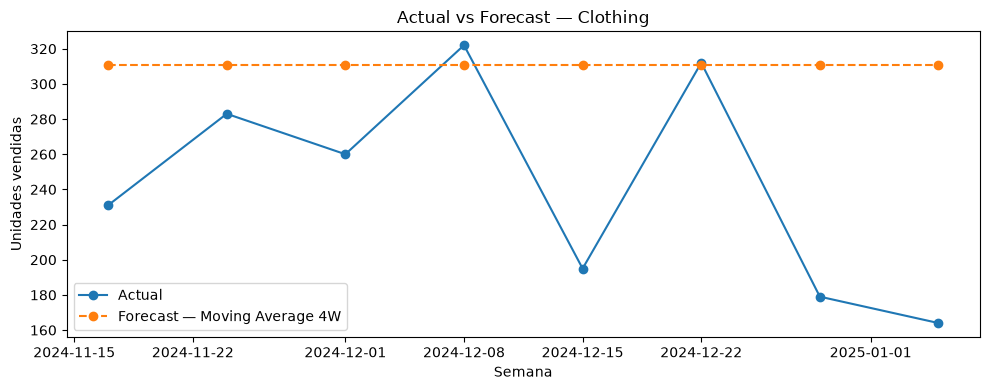

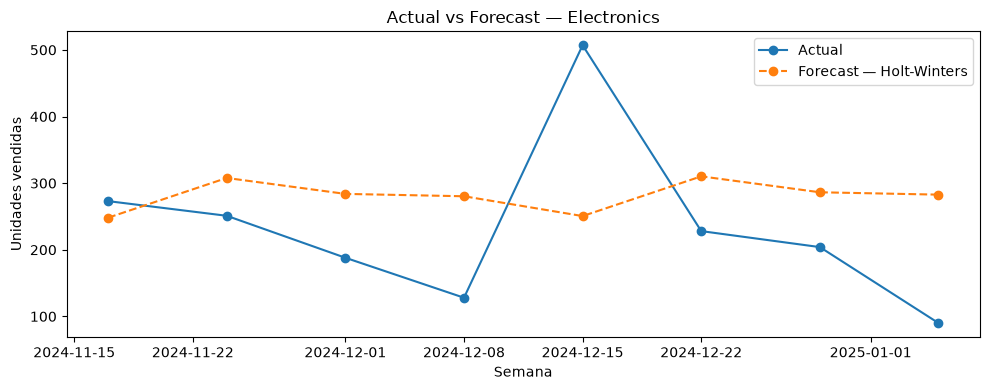

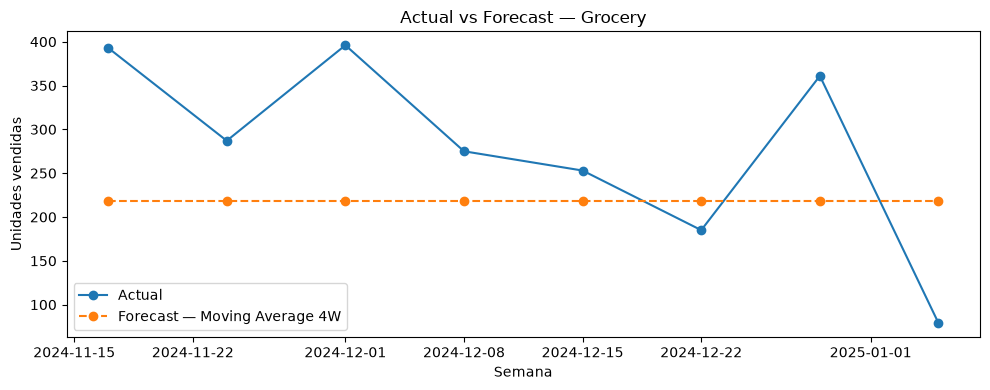

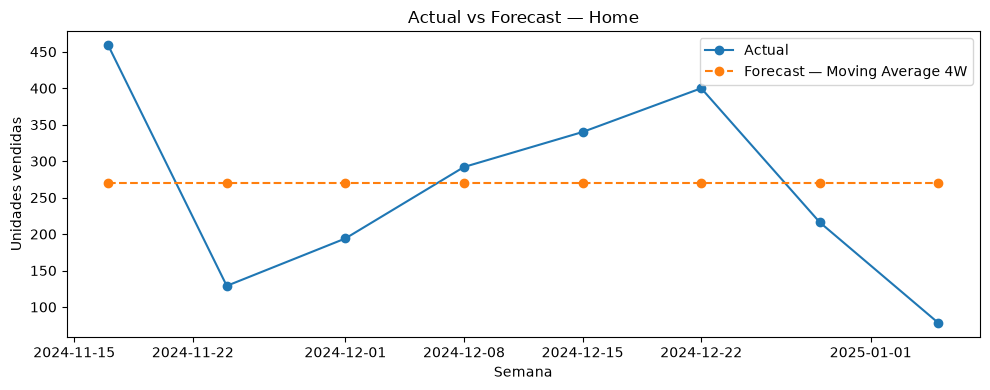

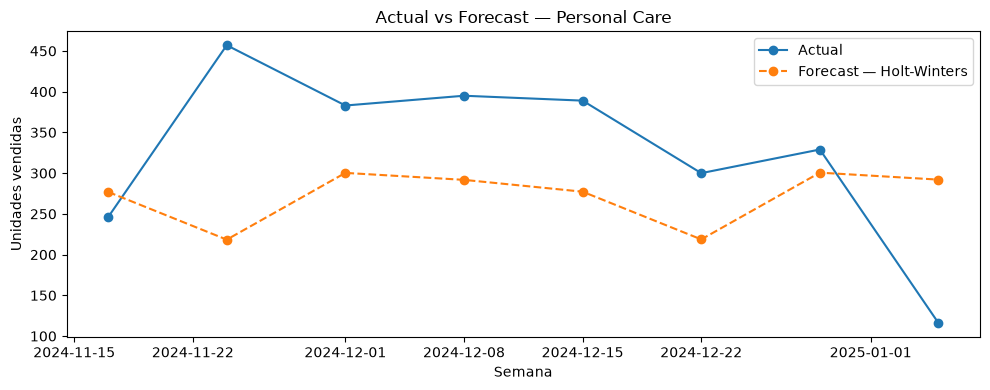

In [11]:
previsoes_teste_df = pd.DataFrame(previsoes_teste)

for _, linha in melhor_modelo.iterrows():

    categoria = linha["category"]
    modelo = linha["model"]

    temp = previsoes_teste_df[
        (previsoes_teste_df["category"] == categoria) &
        (previsoes_teste_df["model"] == modelo)
    ].copy()

    plt.figure(figsize=(10, 4))

    plt.plot(
        temp["date"],
        temp["actual"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        temp["date"],
        temp["forecast"],
        marker="o",
        linestyle="--",
        label=f"Forecast — {modelo}"
    )

    plt.title(f"Actual vs Forecast — {categoria}")
    plt.xlabel("Semana")
    plt.ylabel("Unidades vendidas")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 11. Forecast futuro

Após selecionar o melhor modelo de cada categoria, treinamos novamente usando todo o histórico disponível.

O horizonte inicial será de 8 semanas.


In [12]:
FORECAST_HORIZON = 8

future_forecasts = []

for _, linha in melhor_modelo.iterrows():

    categoria = linha["category"]
    modelo = linha["model"]

    dados_cat = (
        weekly[weekly["category"] == categoria]
        .sort_values("date")
        .reset_index(drop=True)
    )

    ultima_data = dados_cat["date"].max()

    datas_futuras = pd.date_range(
        start=ultima_data + pd.Timedelta(weeks=1),
        periods=FORECAST_HORIZON,
        freq="W-SUN"
    )

    if modelo == "Naive":
        pred = forecast_naive(
            dados_cat,
            FORECAST_HORIZON
        )

    elif modelo == "Moving Average 4W":
        pred = forecast_moving_average(
            dados_cat,
            FORECAST_HORIZON,
            window=4
        )

    elif modelo == "Holt-Winters":
        pred = forecast_holt_winters(
            dados_cat,
            FORECAST_HORIZON
        )

    for data, previsto in zip(datas_futuras, pred):

        future_forecasts.append({
            "category": categoria,
            "date": data,
            "forecast_units": max(0, float(previsto)),
            "selected_model": modelo
        })

future_forecast_df = pd.DataFrame(future_forecasts)

display(future_forecast_df.head(20))


,category,date,forecast_units,selected_model
0,Clothing,2025-01-12,212.50,Moving Average 4W
1,Clothing,2025-01-19,212.50,Moving Average 4W
2,Clothing,2025-01-26,212.50,Moving Average 4W
3,Clothing,2025-02-02,212.50,Moving Average 4W
4,Clothing,2025-02-09,212.50,Moving Average 4W
5,Clothing,2025-02-16,212.50,Moving Average 4W
6,Clothing,2025-02-23,212.50,Moving Average 4W
7,Clothing,2025-03-02,212.50,Moving Average 4W
8,Electronics,2025-01-12,254.93,Holt-Winters
9,Electronics,2025-01-19,282.23,Holt-Winters


## 12. Visualização do forecast futuro


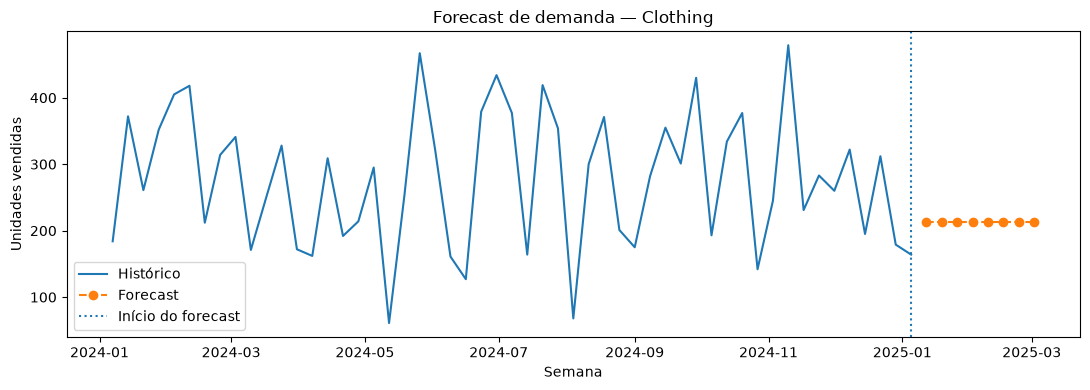

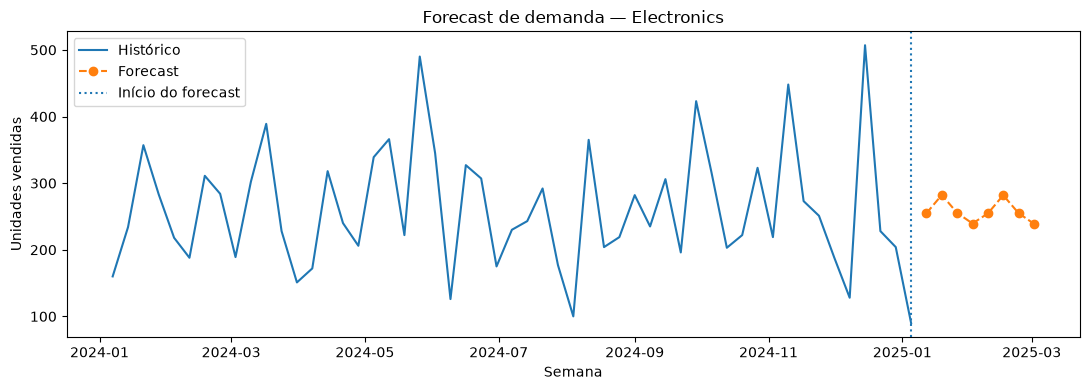

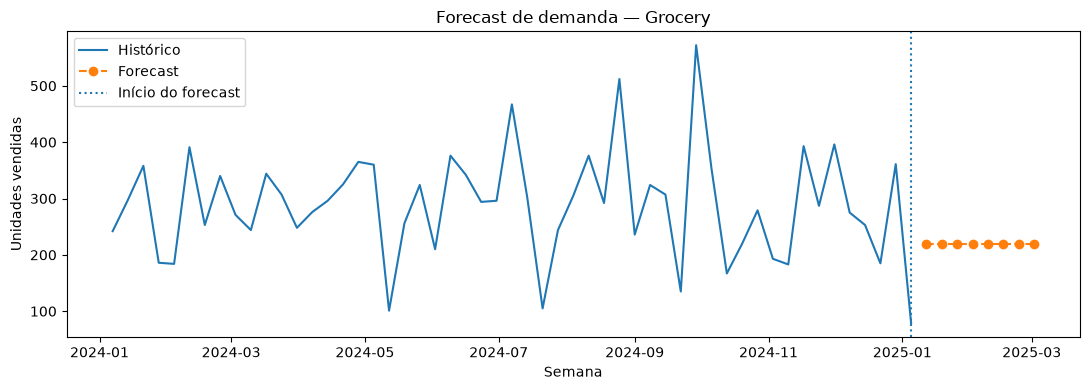

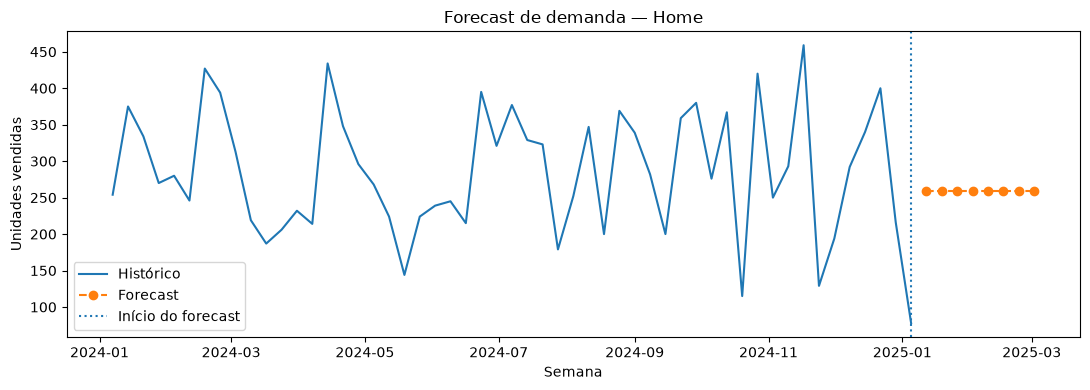

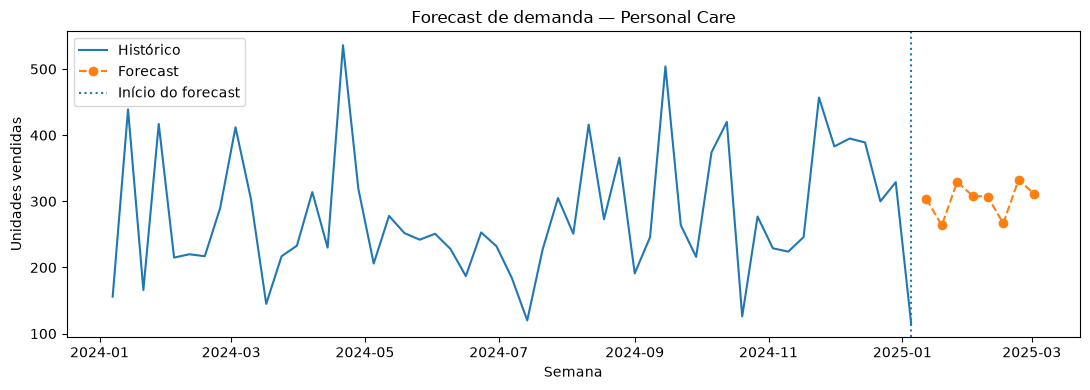

In [13]:
for categoria in future_forecast_df["category"].unique():

    historico = weekly[
        weekly["category"] == categoria
    ].copy()

    futuro = future_forecast_df[
        future_forecast_df["category"] == categoria
    ].copy()

    plt.figure(figsize=(11, 4))

    plt.plot(
        historico["date"],
        historico["units_sold"],
        label="Histórico"
    )

    plt.plot(
        futuro["date"],
        futuro["forecast_units"],
        marker="o",
        linestyle="--",
        label="Forecast"
    )

    plt.axvline(
        historico["date"].max(),
        linestyle=":",
        label="Início do forecast"
    )

    plt.title(f"Forecast de demanda — {categoria}")
    plt.xlabel("Semana")
    plt.ylabel("Unidades vendidas")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 13. Exportação dos resultados

Serão gerados três arquivos:

- `forecast_model_comparison.csv`
- `forecast_test_predictions.csv`
- `forecast_future_8_weeks.csv`

O forecast futuro será utilizado na próxima etapa para:

- projeção de receita;
- cenários otimista, base e pessimista;
- planejamento financeiro;
- posterior otimização de estoque com Solver.


In [14]:
resultados_df.to_csv(
    "forecast_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

previsoes_teste_df.to_csv(
    "forecast_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

future_forecast_df.to_csv(
    "forecast_future_8_weeks.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos gerados:")
print("- forecast_model_comparison.csv")
print("- forecast_test_predictions.csv")
print("- forecast_future_8_weeks.csv")


Arquivos gerados:
- forecast_model_comparison.csv
- forecast_test_predictions.csv
- forecast_future_8_weeks.csv
